In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/dikshachakraborty01
/kaggle/input/datasets/dikshachakraborty01/merged-annotated-dataset
/kaggle/input/datasets/dikshachakraborty01/cluster-of-annotated-chunks
/kaggle/input/datasets/dikshachakraborty01/filtered-dataset-49k


# **Uploading and Merging the chunks**

In [2]:
import pandas as pd
import glob


path = "/kaggle/input/datasets/dikshachakraborty01/cluster-of-annotated-chunks/*.csv"


csv_files = glob.glob(path)

df_list = []

for file in csv_files:
    df = pd.read_csv(file)
    df_list.append(df)


merged_df = pd.concat(df_list, ignore_index=True)


print(merged_df.shape)


merged_df.to_csv("/kaggle/working/final_merged_dataset.csv", index=False)

print("CSV files merged successfully!")

merged_df.head()

(10749, 4)
CSV files merged successfully!


,clean_text,final_label,corrected_label,one_text
0,i will think about it,neutral,NaN,NaN
1,tourism lags in bushs hometown,neutral,NaN,NaN
2,okay monica right foot red,neutral,NaN,NaN
3,hey ross this probably isnt the best time to b...,neutral,NaN,NaN
4,needs a partner in crime,sadness,neutral,NaN


# **Cleaning and Fine-tuning the merged dataset**

## **Importing dataset**

In [3]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/dikshachakraborty01/merged-annotated-dataset/annotated_merged_dataset.csv')

df.head()
print("Total number of rows:", len(df))

Total number of rows: 10749


## **Removing ambiguous rows**

In [4]:
df = df[df["corrected_label"] != "?"]

print("Rows remaining after removing '?':", len(df))

Rows remaining after removing '?': 10050


## **Replacing incorrect labels with the corrected one**

In [5]:
df["final_label"] = df["corrected_label"].fillna(df["final_label"])


df["final_label"] = df.apply(
    lambda row: row["corrected_label"]
    if pd.notna(row["corrected_label"]) and str(row["corrected_label"]).strip() != ""
    else row["final_label"],
    axis=1
)

## **Deleting extra column**

In [6]:
df = df.drop(columns=["corrected_label"])


df.head()

,clean_text,final_label
0,i will think about it,neutral
1,tourism lags in bushs hometown,neutral
2,okay monica right foot red,neutral
3,hey ross this probably isnt the best time to b...,neutral
4,needs a partner in crime,neutral


## **Checking class distribution**

In [7]:
distribution = pd.DataFrame({
    "Count": df["final_label"].value_counts(),
    "Percentage": (df["final_label"].value_counts(normalize=True) * 100).round(2)
})

print(distribution)

             Count  Percentage
final_label                   
neutral       4321       43.00
joy           1364       13.57
anger         1136       11.30
sadness        885        8.81
disgust        879        8.75
fear           600        5.97
surprise       520        5.17
Neutral        144        1.43
Anger           83        0.83
Sadness         38        0.38
Disgust         35        0.35
Joy             24        0.24
Surprise        12        0.12
confused         3        0.03
Fear             2        0.02
jOY              2        0.02
concern          1        0.01
tensed           1        0.01


## **Convert labels to lowercase and remove extra spaces**

In [8]:
df["final_label"] = df["final_label"].str.lower().str.strip()

## **Mapping unwanted labels to valid emotion classes**

In [9]:
valid_emotions = [
    "joy",
    "sadness",
    "disgust",
    "anger",
    "fear",
    "surprise",
    "neutral"
]

In [10]:
label_mapping = {
    "concern": "fear",
    "tensed": "fear",
    "confused": "neutral"
}


df["final_label"] = df["final_label"].replace(label_mapping)

## **Removing rows with "?" label**

In [11]:
df = df[df["final_label"] != "?"]

## **Checking for inconsistencies**

In [12]:
df = df[df["final_label"].isin(valid_emotions)]

print("Remaining rows:", len(df))

Remaining rows: 10050


In [13]:
distribution = pd.DataFrame({
    "Count": df["final_label"].value_counts(),
    "Percentage": (df["final_label"].value_counts(normalize=True) * 100).round(2)
})

print(distribution)

             Count  Percentage
final_label                   
neutral       4468       44.46
joy           1390       13.83
anger         1219       12.13
sadness        923        9.18
disgust        914        9.09
fear           604        6.01
surprise       532        5.29


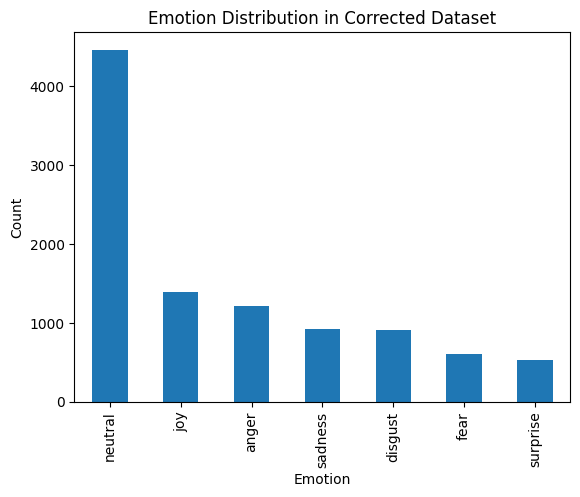

In [14]:
import matplotlib.pyplot as plt

df["final_label"].value_counts().plot(kind="bar")

plt.xlabel("Emotion")
plt.ylabel("Count")
plt.title("Emotion Distribution in Corrected Dataset")

plt.show()

In [15]:
df.to_csv("/kaggle/working/cleaned_corrected_dataset.csv", index=False)

print("Cleaned corrected dataset saved!")

Cleaned corrected dataset saved!


# **Importing the other half of the MAIN dataset**

In [16]:
main_df = pd.read_csv("/kaggle/input/datasets/dikshachakraborty01/filtered-dataset-49k/cleaned_emotion_dataset_v2.csv")

print("Main dataset shape:", main_df.shape)
print("Corrected dataset shape:", df.shape)

Main dataset shape: (49947, 2)
Corrected dataset shape: (10050, 2)


# **Merging both the datasets**

In [17]:
final_dataset = pd.concat([main_df, df], ignore_index=True)

print("Final merged dataset shape:", final_dataset.shape)

Final merged dataset shape: (59997, 2)


# **Saving the final cleaned dataset**

In [18]:
final_dataset.to_csv("/kaggle/working/final_cleaned_dataset.csv", index=False)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!
